In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

In [2]:
EXPERIMENT_DIR = Path("experiments/test")
TRAIN_TASK = "countdown"
TASKS = ["countdown", "gsm8k", "proofwriter", "hellaswag", "mmlu-pro", "arc-challenge", "piqa"]
EVAL_TASKS = [task for task in TASKS if task != TRAIN_TASK]
TASK_LABELS = {
    "countdown": "Countdown",
    "gsm8k": "GSM8K",
    "proofwriter": "ProofWriter",
    "hellaswag": "HellaSwag",
    "mmlu-pro": "MMLU-Pro",
    "arc-challenge": "ARC-Challenge",
    "piqa": "PIQA",
}

RUN_CONFIGS = [
    {
        "label": "ES (30)",
        "path": EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed1_popsize30_msFalse_20260328_123119",
        "marker": "o",
    },
    {
        "label": "ES (30) + AWD",
        "path": EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l2wd10.0_20260421_151321",
        "marker": "*",
    },
]

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "evaluation").exists():
    if (REPO_ROOT.parent / "evaluation").exists():
        REPO_ROOT = REPO_ROOT.parent
    else:
        raise RuntimeError("Run this notebook from the repo root or evaluation directory.")

In [3]:
def resolve_path(path: Path):
    path = Path(path)
    return path if path.is_absolute() else REPO_ROOT / path


def load_metrics(run_dir: Path, task_name: str):
    path = run_dir / f"{task_name}.jsonl"
    empty_frame = pd.DataFrame(columns=["step", f"{task_name}_accuracy"])
    if not path.is_file():
        print(f"Missing metrics file for {task_name}: {path}")
        return empty_frame, path, False

    records = [json.loads(line) for line in path.read_text().splitlines() if line.strip()]
    if not records:
        print(f"No records found in {path}")
        return empty_frame, path, False

    frame = pd.DataFrame(records).sort_values("step").reset_index(drop=True)
    frame = frame.rename(columns={"accuracy": f"{task_name}_accuracy"})
    return frame, path, True


def read_model_name(run_dir: Path):
    args_path = run_dir / "args.json"
    if args_path.is_file():
        return json.loads(args_path.read_text()).get("model_name")
    return None


def build_run_spec(config):
    run_dir = resolve_path(config["path"])
    train_df, train_path, train_available = load_metrics(run_dir, TRAIN_TASK)
    if train_available:
        print(f"Loaded {config['label']} train metrics: {train_path}")
    else:
        print(f"{config['label']} train metrics unavailable: {train_path}")

    eval_frames = {}
    eval_available = {}
    for task_name in EVAL_TASKS:
        eval_df, eval_path, is_available = load_metrics(run_dir, task_name)
        eval_frames[task_name] = eval_df
        eval_available[task_name] = is_available
        if is_available:
            print(f"Loaded {config['label']} eval metrics: {eval_path}")
        else:
            print(f"{config['label']} eval metrics unavailable for {task_name}: {eval_path}")

    return {
        "label": config["label"],
        "run_dir": run_dir,
        "model_name": read_model_name(run_dir),
        "marker": config["marker"],
        "train_df": train_df,
        "train_available": train_available,
        "eval_frames": eval_frames,
        "eval_available": eval_available,
    }


def average_prior_task_accuracy(run_spec):
    prior_accuracy_frames = []
    for task_name in EVAL_TASKS:
        accuracy_col = f"{task_name}_accuracy"
        if not run_spec["eval_available"].get(task_name, False):
            continue
        eval_df = run_spec["eval_frames"][task_name]
        if accuracy_col not in eval_df.columns:
            continue
        prior_accuracy_frames.append(eval_df[["step", accuracy_col]])

    if not prior_accuracy_frames:
        return pd.DataFrame(columns=["step", "avg_prior_accuracy"])

    avg_prior_df = prior_accuracy_frames[0].copy()
    for eval_df in prior_accuracy_frames[1:]:
        avg_prior_df = avg_prior_df.merge(eval_df, on="step", how="outer")

    accuracy_cols = [col for col in avg_prior_df.columns if col != "step"]
    avg_prior_df["avg_prior_accuracy"] = avg_prior_df[accuracy_cols].mean(axis=1)
    return avg_prior_df[["step", "avg_prior_accuracy"]].sort_values("step").reset_index(drop=True)


RUN_SPECS = [build_run_spec(config) for config in RUN_CONFIGS]

Loaded ES (30) train metrics: /home/kajetan/es_finetuning/experiments/test/Qwen2.5-3B-Instruct_countdown_seed1_popsize30_msFalse_20260328_123119/countdown.jsonl
Loaded ES (30) eval metrics: /home/kajetan/es_finetuning/experiments/test/Qwen2.5-3B-Instruct_countdown_seed1_popsize30_msFalse_20260328_123119/gsm8k.jsonl
Loaded ES (30) eval metrics: /home/kajetan/es_finetuning/experiments/test/Qwen2.5-3B-Instruct_countdown_seed1_popsize30_msFalse_20260328_123119/proofwriter.jsonl
Loaded ES (30) eval metrics: /home/kajetan/es_finetuning/experiments/test/Qwen2.5-3B-Instruct_countdown_seed1_popsize30_msFalse_20260328_123119/hellaswag.jsonl
Loaded ES (30) eval metrics: /home/kajetan/es_finetuning/experiments/test/Qwen2.5-3B-Instruct_countdown_seed1_popsize30_msFalse_20260328_123119/mmlu-pro.jsonl
Loaded ES (30) eval metrics: /home/kajetan/es_finetuning/experiments/test/Qwen2.5-3B-Instruct_countdown_seed1_popsize30_msFalse_20260328_123119/arc-challenge.jsonl
Loaded ES (30) eval metrics: /home/kaj

In [4]:
step_series = []
for run_index, run_spec in enumerate(RUN_SPECS):
    if not run_spec["train_df"].empty:
        step_series.append(run_spec["train_df"]["step"])
    for eval_df in run_spec["eval_frames"].values():
        if not eval_df.empty:
            step_series.append(eval_df["step"])

if step_series:
    all_steps = pd.concat(step_series, ignore_index=True)
    norm = Normalize(vmin=all_steps.min(), vmax=all_steps.max())
else:
    norm = Normalize(vmin=0, vmax=1)

LEGEND_HANDLES = [
    Line2D(
        [0],
        [0],
        marker=run_spec["marker"],
        linestyle="",
        markerfacecolor="0.45",
        markeredgecolor="0.25",
        markersize=8 if run_spec["marker"] == "o" else 10,
        label=run_spec["label"],
    )
    for run_spec in RUN_SPECS
]

model_names = {run_spec["model_name"] for run_spec in RUN_SPECS if run_spec["model_name"]}
TITLE_MODEL_NAME = " | ".join(sorted(model_names))

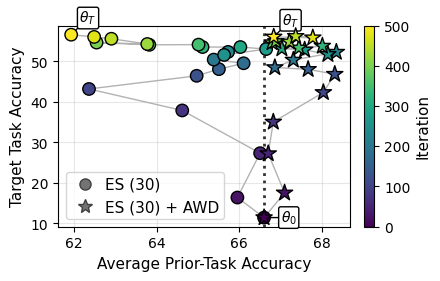

In [7]:
fig, ax = plt.subplots(figsize=(4.3, 2.7), constrained_layout=True)
ax.set_xlabel("Average Prior-Task Accuracy", fontsize=11)
ax.set_ylabel("Target Task Accuracy", fontsize=11)
ax.grid(alpha=0.3)

scatter_artist = None
plotted_any = False
messages = []
original_prior_accuracy = None
train_accuracy_col = f"{TRAIN_TASK}_accuracy"

for r, run_spec in enumerate(RUN_SPECS):
    if not run_spec["train_available"]:
        messages.append(f"{run_spec['label']}: missing {TRAIN_TASK} metrics")
        continue

    avg_prior_df = average_prior_task_accuracy(run_spec)
    if avg_prior_df.empty:
        messages.append(f"{run_spec['label']}: missing prior task metrics")
        continue

    merged = run_spec["train_df"][["step", train_accuracy_col]].merge(
        avg_prior_df,
        on="step",
        how="inner",
    )
    if merged.empty:
        messages.append(f"{run_spec['label']}: no overlapping steps")
        continue

    merged = merged.sort_values("step")
    if original_prior_accuracy is None:
        original_prior_accuracy = merged.iloc[0]["avg_prior_accuracy"]

    ax.plot(
        merged["avg_prior_accuracy"],
        merged[train_accuracy_col],
        color="black",
        linewidth=1.0,
        alpha=0.3,
        zorder=1,
    )

    scatter_artist = ax.scatter(
        merged["avg_prior_accuracy"],
        merged[train_accuracy_col],
        c=merged["step"],
        cmap="viridis",
        norm=norm,
        s=80 if run_spec["marker"] == "o" else 150,
        edgecolors="black",
        marker=run_spec["marker"],
        alpha=1,
        zorder=99,
    )

    for point, label, horizontal_offset, horizontal_alignment in [
        (merged.iloc[0], r"$\theta_0$", 12, "left"),
        (merged.iloc[-1], r"$\theta_T$", 6, "left"),
    ]:  
        if r > 0 and label == r"$\theta_0$":
            continue

        ax.annotate(
            label,
            xy=(point["avg_prior_accuracy"], point[train_accuracy_col]),
            xytext=(horizontal_offset, 12 if label == r"$\theta_T$" else 0),
            textcoords="offset points",
            ha=horizontal_alignment,
            va="center",
            color="black",
            fontsize=10,
            bbox={"boxstyle": "round,pad=0.15", "facecolor": "white", "edgecolor": "black", "alpha": 1},
            arrowprops={"arrowstyle": "-", "color": "black", "linewidth": 1, "alpha": 1, "shrinkA": 0, "shrinkB": 0},
            zorder=98,
        )
    plotted_any = True

if not plotted_any:
    ax.text(
        0.5,
        0.5,
        "\n".join(messages) if messages else "No data available",
        ha="center",
        va="center",
        transform=ax.transAxes,
        color="0.4",
    )
elif scatter_artist is not None:
    cb = fig.colorbar(scatter_artist, ax=ax)
    cb.set_label("Iteration", fontsize=11)

if original_prior_accuracy is not None:
    ax.axvline(
        original_prior_accuracy,
        color="black",
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        zorder=1,
    )

ax.legend(handles=LEGEND_HANDLES, loc="lower left", ncol=1, fontsize=11, handletextpad=0.3, borderpad=0.3)
# fig.suptitle(TITLE_MODEL_NAME)
plt.savefig("main_figure.pdf", bbox_inches="tight")
plt.show()